In [1]:
library(cubature)
library(MASS)
library(pracma)
library(mvtnorm)

library(LogConcDEAD)
library(logcondens) 
library(mclust)

source('lcic.r')

Warning message:
“no DISPLAY variable so Tk is not available”
Package 'mclust' version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:mvtnorm’:

    dmvnorm




# Check results

In [2]:
all_results <- list()
all_d <- c(2,3,4)
for (dind in 1:length(all_d)) {
    filename <- sprintf('Results/yuan_samworth_over_n_d=%s.RData', all_d[dind])
    all_results[[dind]] <- readRDS(filename)
}

all_results_ica <- list()
all_d <- c(2,3,4)
for (dind in 1:length(all_d)) {
    filename <- sprintf('Results/fastICA_over_n_d=%s.RData', all_d[dind])
    all_results_ica[[dind]] <- readRDS(filename)
}

all_results_comb <- list()
all_d <- c(2,3,4)
for (dind in 1:length(all_d)) {
    filename <- sprintf('Results/yuan_samworth_fastica_init_over_n_d=%s.RData', all_d[dind])
    all_results_comb[[dind]] <- readRDS(filename)
}

In [3]:
# Convert to matrix
all_n <- c(100, 500, 1000, 2000, 3000)

convert_to_matrix <- function(retrieved_comparison_data) {

    num_exp <- length(retrieved_comparison_data)
    results_mat <- matrix(nrow=num_exp ,ncol=5)
    colnames(results_mat) <- c("n", "d", "irep", "time_taken", "hell_err_mean")
    
    for (eind in 1:num_exp){
        results_mat[eind, "n"] <- retrieved_comparison_data[[eind]]$n
        results_mat[eind, "d"] <- retrieved_comparison_data[[eind]]$d
        results_mat[eind, "irep"] <- retrieved_comparison_data[[eind]]$irep
        results_mat[eind, "time_taken"] <- retrieved_comparison_data[[eind]]$time_taken
        results_mat[eind, "hell_err_mean"] <- retrieved_comparison_data[[eind]]$hell_err_mean
    }
    return(results_mat)
    
}

get_ave_metric <- function(results_mat, all_n, metric_string){
    num_n_vals <- length(all_n)
    ave_metric_vec <- rep(0,num_n_vals)
    for (nvind in 1:num_n_vals){
        where_n <- (results_mat[,"n"]==all_n[nvind])
        ave_metric_vec[nvind] <- mean(results_mat[where_n, metric_string])
    }
    return(ave_metric_vec)
}


In [4]:
all_results_mats <- list()
all_results_mats_ica <- list()
all_results_mats_comb <- list()

for (dind in 1:3){
    all_results_mats[[dind]] <- convert_to_matrix(all_results[[dind]])
    all_results_mats_ica[[dind]] <- convert_to_matrix(all_results_ica[[dind]])
    all_results_mats_comb[[dind]] <- convert_to_matrix(all_results_comb[[dind]])
}

all_results_mats[[1]]
all_results_mats_ica[[1]]
all_results_mats_comb[[1]]

n,d,irep,time_taken,hell_err_mean
100,2,1,16.255612,0.0673001004
100,2,2,6.508289,0.0404399585
100,2,3,18.156317,0.0978994202
100,2,4,19.846790,0.0843021092
100,2,5,2.736270,0.0984914493
500,2,1,38.157992,0.0474581590
500,2,2,9.047020,0.0478982657
500,2,3,34.974409,0.0107231986
500,2,4,29.239108,0.0164642763
500,2,5,31.981088,0.0065353244


n,d,irep,time_taken,hell_err_mean
100,2,1,0.034166336,0.044525223
100,2,2,0.020654440,0.028253863
100,2,3,0.005718708,0.041988372
100,2,4,0.007316828,0.039254426
100,2,5,0.007862806,0.042713861
500,2,1,0.014621496,0.016974542
500,2,2,0.008193731,0.019080620
500,2,3,0.015518904,0.007376590
500,2,4,0.015511751,0.011036425
500,2,5,0.019917011,0.010768445


n,d,irep,time_taken,hell_err_mean
100,2,1,5.1426022,0.0204919521
100,2,2,4.2894528,0.0144005478
100,2,3,0.3390796,0.0258374454
100,2,4,4.9771969,0.1146224260
100,2,5,0.1999369,0.0234267985
500,2,1,0.8646977,0.0060274800
500,2,2,11.5684004,0.0040980868
500,2,3,10.5296028,0.0071535656
500,2,4,0.7726500,0.0032855471
500,2,5,11.3134072,0.0051661728


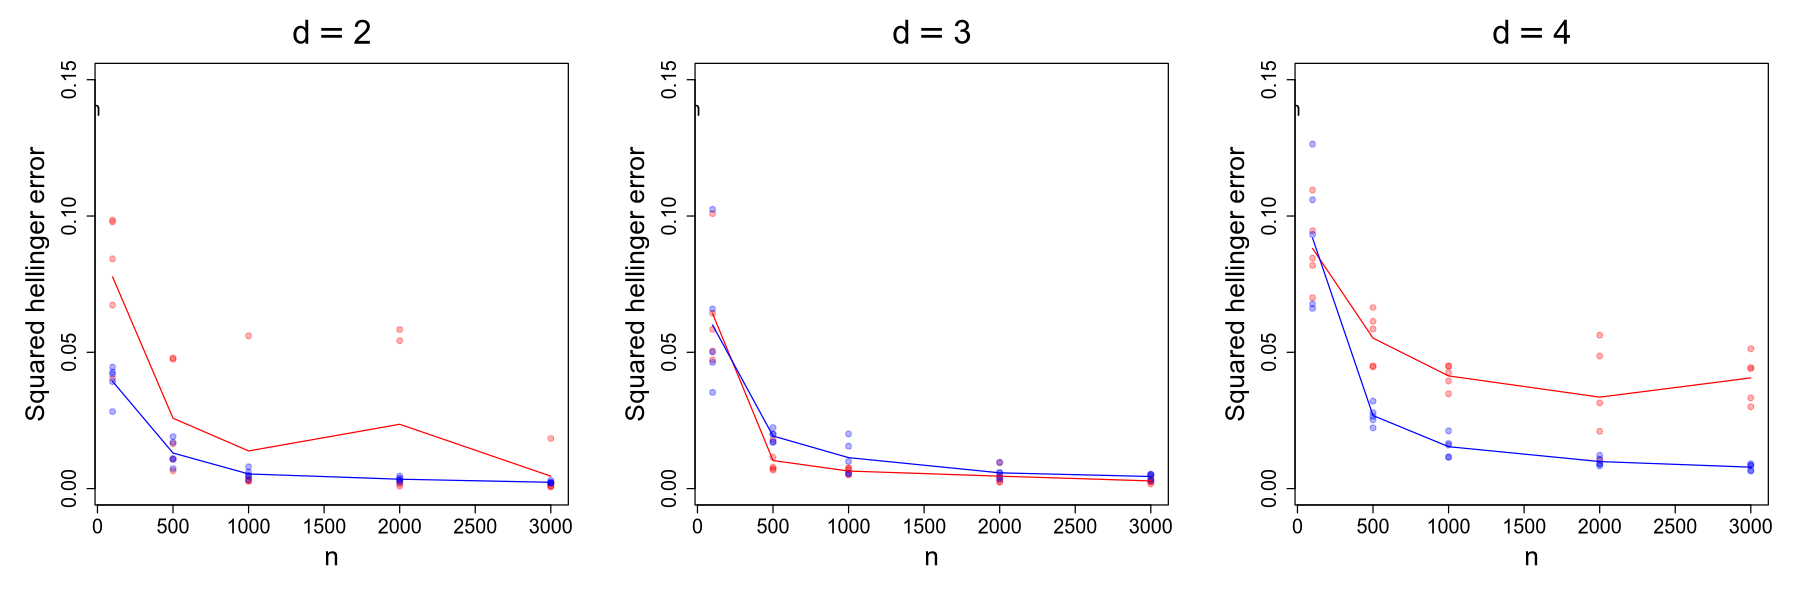

In [7]:
# pdf(file='Results/new-figures/uniform-samworth-yuan.pdf', width=15, height=5)

options(repr.plot.width = 15, repr.plot.height = 5)
par(mfrow = c(1, 3), mar=c(6,6,4,2))

point_alpha <- 0.3
line_alpha <- 1
pch <- 19
lty <- 1

all_n <- c(100, 500, 1000, 2000, 3000)

for (dind in 1:3) {

     plot(x=all_results_mats[[dind]][,"n"], y=all_results_mats[[dind]][,"hell_err_mean"], pch=pch, col=rgb(1,0,0,point_alpha), main=bquote(d == .(all_d[dind])),
     cex.lab=2, cex.axis=1.5, cex.main=2.5, xlab=expression(n), ylab="Squared hellinger error", ylim=c(0,0.15))
     points(x=all_results_mats_ica[[dind]][,"n"], y=all_results_mats_ica[[dind]][,"hell_err_mean"], pch=pch, col=rgb(0,0,1,point_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats[[dind]], all_n, "hell_err_mean"), lty=lty, col=rgb(1,0,0,line_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats_ica[[dind]], all_n, "hell_err_mean"), lty=lty, col=rgb(0,0,1,line_alpha))
     legend(x="topright", legend=c("LC-IC", "Samworth and Yuan"), col=c(rgb(0,0,1,1), rgb(1,0,0,1)), lty=c(lty,lty), 
       cex=1.5, seg.len=3, y.intersp=1.5, bty="n")

}

# dev.off()




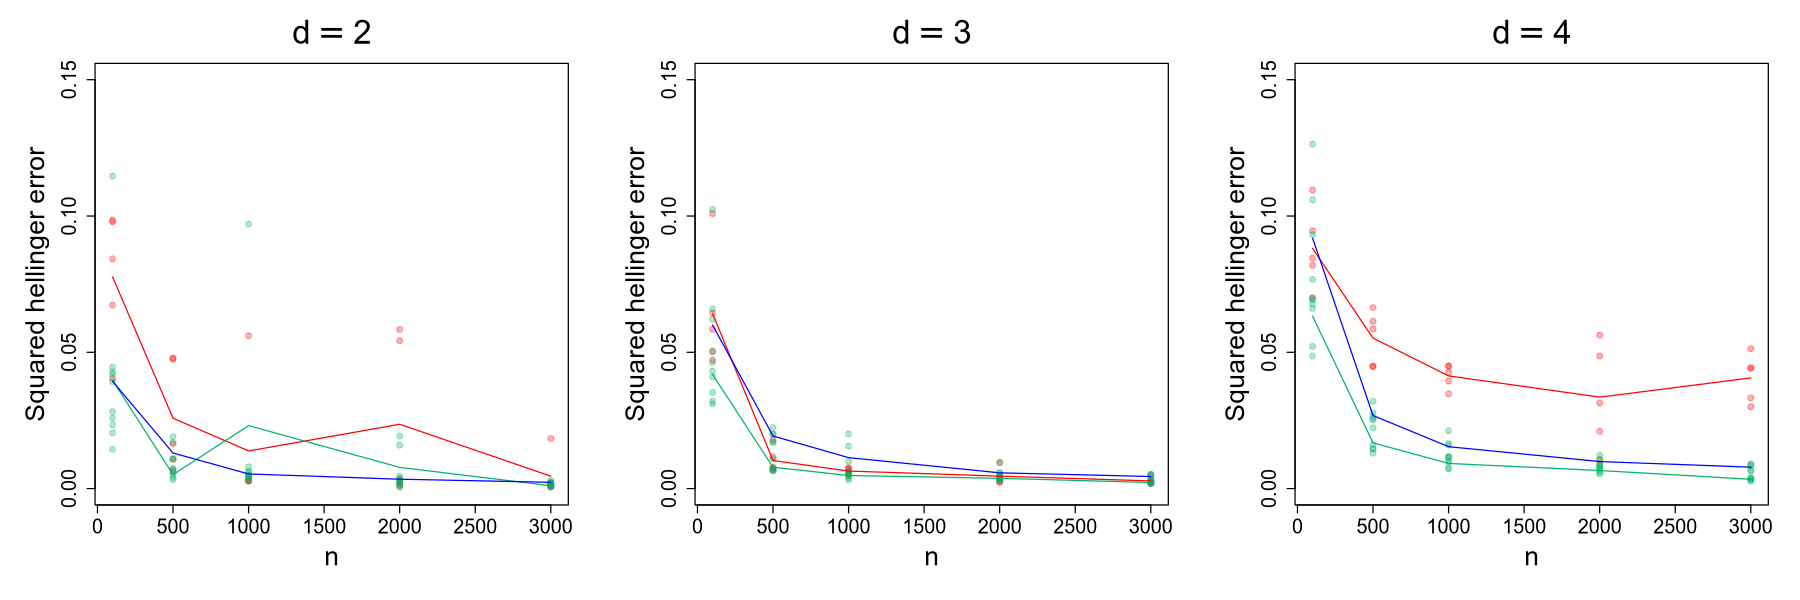

In [15]:
# pdf(file='Results/new-figures/fast-ica-init-uniform-samworth-yuan.pdf', width=15, height=5)

options(repr.plot.width = 15, repr.plot.height = 5)
par(mfrow = c(1, 3), mar=c(6,6,4,2))

point_alpha <- 0.3
line_alpha <- 1
pch <- 19
lty <- 1

all_n <- c(100, 500, 1000, 2000, 3000)

for (dind in 1:3) {

     plot(x=all_results_mats[[dind]][,"n"], y=all_results_mats[[dind]][,"hell_err_mean"], pch=pch, col=rgb(1,0,0,point_alpha), main=bquote(d == .(all_d[dind])),
     cex.lab=2, cex.axis=1.5, cex.main=2.5, xlab=expression(n), ylab="Squared hellinger error", ylim=c(0,0.15))
     points(x=all_results_mats_comb[[dind]][,"n"], y=all_results_mats_comb[[dind]][,"hell_err_mean"], pch=pch, col=rgb(0,0.7,0.4,point_alpha))
     points(x=all_results_mats_ica[[dind]][,"n"], y=all_results_mats_ica[[dind]][,"hell_err_mean"], pch=pch, col=rgb(0,0.7,0.4,point_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats[[dind]], all_n, "hell_err_mean"), lty=lty, col=rgb(1,0,0,line_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats_comb[[dind]], all_n, "hell_err_mean"), lty=lty, col=rgb(0,0.7,0.4,line_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats_ica[[dind]], all_n, "hell_err_mean"), lty=lty, col=rgb(0,0,1,line_alpha))
     legend(x="topright", legend=c("LC-IC", "LogConICA", "LC-IC initialized LogConICA"), col=c(rgb(0,0,1,1), rgb(1,0,0,1), rgb(0,0.7,0.4,1)), lty=c(lty,lty), 
       cex=1.5, seg.len=3, y.intersp=1.5, bty="n")

}

# dev.off()




In [25]:
print(all_n)
num_random_initializations <- 10
for (dind in 1:3){

    print(get_ave_metric(all_results_mats[[dind]], all_n, "time_taken")/num_random_initializations)
    print(get_ave_metric(all_results_mats_ica[[dind]], all_n, "time_taken"))
}



[1]  100  500 1000 2000 3000
[1]  1.270066  2.867992  9.167905 24.921998 41.641242
[1] 0.01514382 0.01475258 0.02411613 0.03802481 0.06201062
[1]  0.3819058  2.9938165  4.0062458 15.9922002 31.3501581
[1] 0.01517830 0.02698174 0.05110908 0.08743501 0.10105872
[1]  0.4406099  1.4924028  3.2234409  7.5968453 12.3323591
[1] 0.01910777 0.04355278 0.09725795 0.12052007 0.17839746


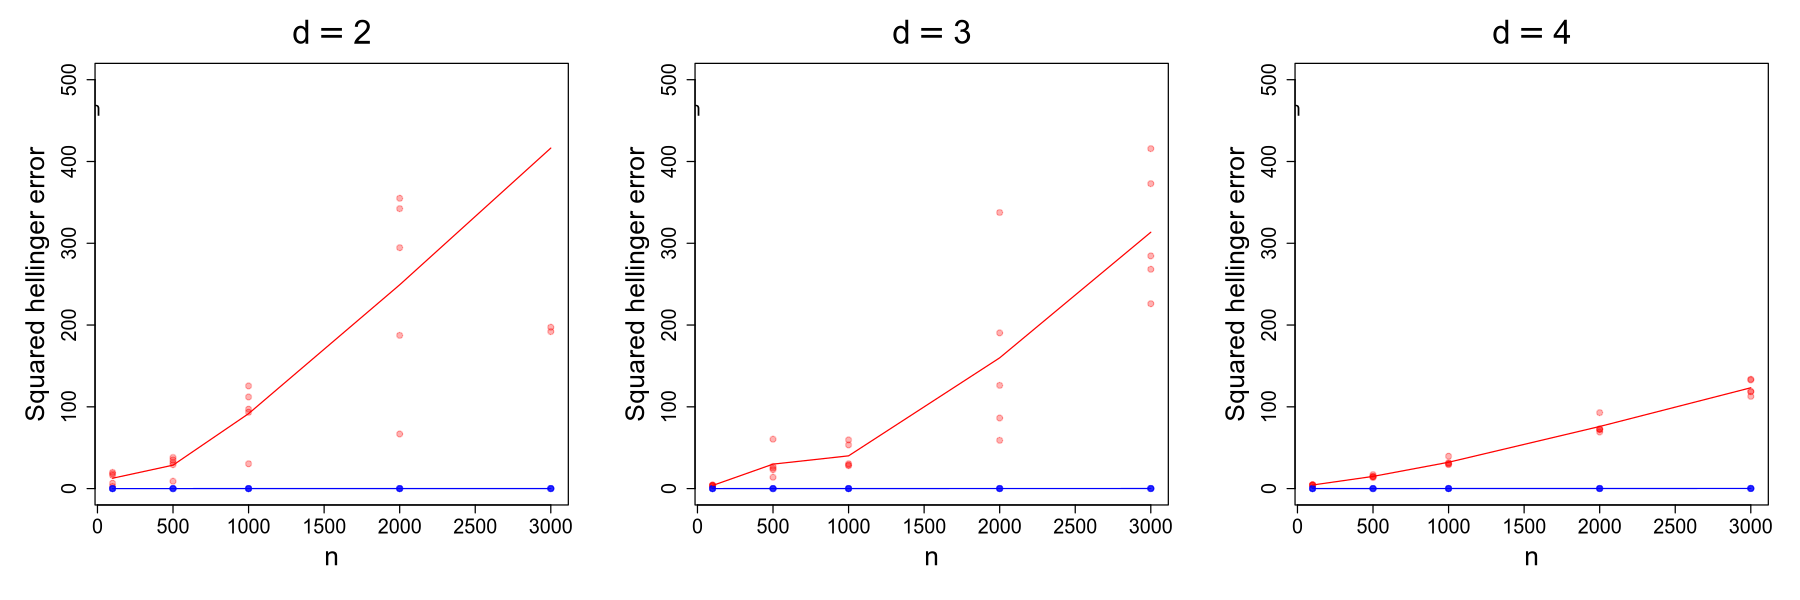

In [28]:
# pdf(file='Results/new-figures/uniform-samworth-yuan.pdf', width=15, height=5)

options(repr.plot.width = 15, repr.plot.height = 5)
par(mfrow = c(1, 3), mar=c(6,6,4,2))

point_alpha <- 0.3
line_alpha <- 1
pch <- 19
lty <- 1

all_n <- c(100, 500, 1000, 2000, 3000)

for (dind in 1:3) {

     plot(x=all_results_mats[[dind]][,"n"], y=all_results_mats[[dind]][,"time_taken"], pch=pch, col=rgb(1,0,0,point_alpha), main=bquote(d == .(all_d[dind])),
     cex.lab=2, cex.axis=1.5, cex.main=2.5, xlab=expression(n), ylab="Squared hellinger error", ylim=c(0,500))
     points(x=all_results_mats_ica[[dind]][,"n"], y=all_results_mats_ica[[dind]][,"time_taken"], pch=pch, col=rgb(0,0,1,point_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats[[dind]], all_n, "time_taken"), lty=lty, col=rgb(1,0,0,line_alpha))
     lines(x=all_n, y=get_ave_metric(all_results_mats_ica[[dind]], all_n, "time_taken"), lty=lty, col=rgb(0,0,1,line_alpha))
     legend(x="topright", legend=c("LC-IC", "Samworth and Yuan"), col=c(rgb(0,0,1,1), rgb(1,0,0,1)), lty=c(lty,lty), 
       cex=1.5, seg.len=3, y.intersp=1.5, bty="n")

}

# dev.off()




In [3]:
# Test fastICA

# install.packages('fastICA')
# library(fastICA)
# require('fastICA')
# install.packages('ica')
library('ica')


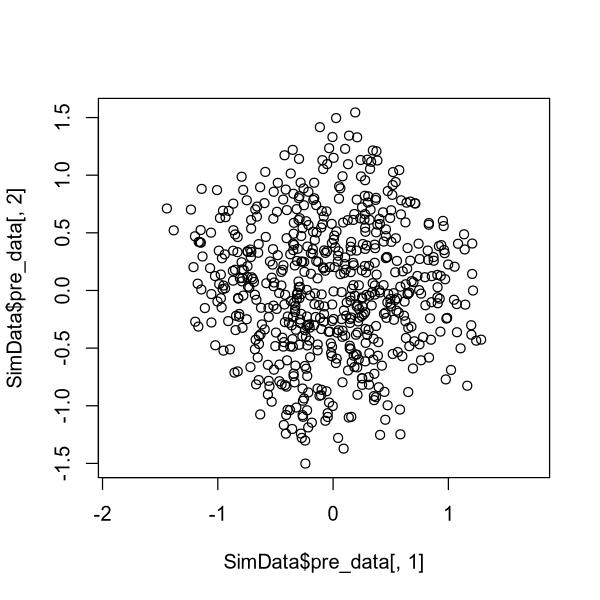

In [29]:
d = 3
n = 600
true_mean_vec <- rep(0,d) 
scalings_vec = rep(1, d)

W <- fix_signs_fun(randortho(d, type="orthonormal"))
SimData <- get_uniform_data(d, n, scalings_vec=scalings_vec, true_mean_vec=true_mean_vec, W=W)


plot(x=SimData$pre_data[,1], y=SimData$pre_data[,2], asp=1)

In [30]:
my_output <- icafast(SimData$pre_data, nc=d, center=FALSE, fun='kur')

qrmat <- qr(t(my_output$W))
W_modified <- t(qr.Q(qrmat))

In [31]:
# my_output$W %*% t(my_output$W) 
# my_output$R %*% t(my_output$R) 
# t(my_output$R) %*% my_output$R
W_modified %*% t(W_modified)


1.000000e+00,-3.485259e-17,6.081780e-17
-3.485259e-17,1.000000e+00,-1.273839e-16
6.081780e-17,-1.273839e-16,1.000000e+00


0.1338620,-0.7176338,-0.6834345
0.5642889,-0.5117235,0.6478557
0.8146527,0.4723777,-0.3364525


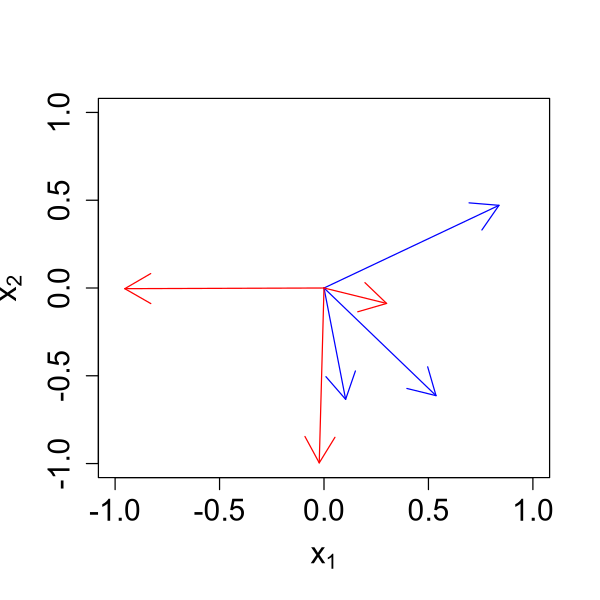

-0.01538324,-0.03307725,-0.99933440
0.99976432,-0.01582062,-0.01486621
-0.01531836,-0.99932758,0.03331283


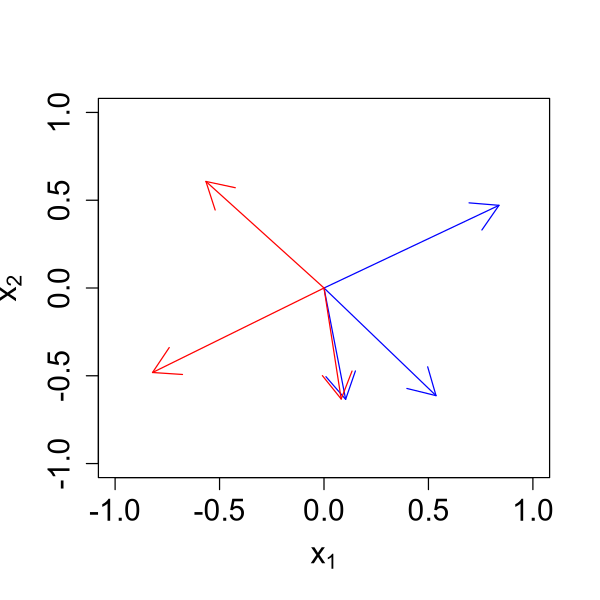

In [32]:
options(repr.plot.width = 5, repr.plot.height = 5)

visualize_independent_directions_from_W(SimData$W, t(my_output$R))
visualize_independent_directions_from_W(SimData$W, W_modified)

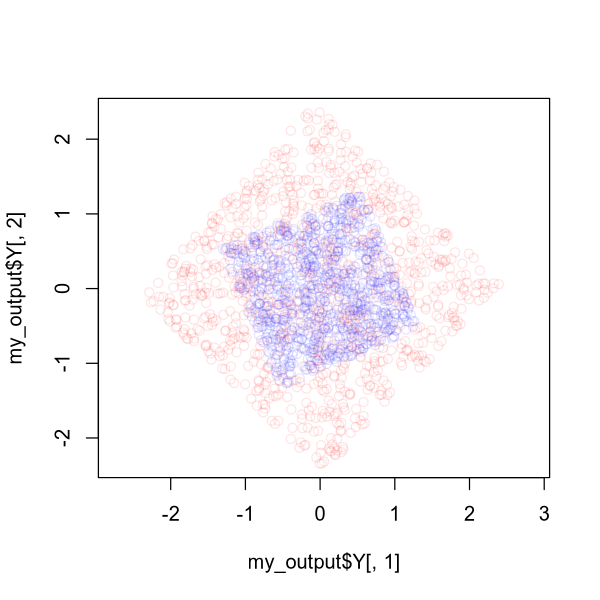

-1.72432971,0.02268839
0.02186177,-1.72681320


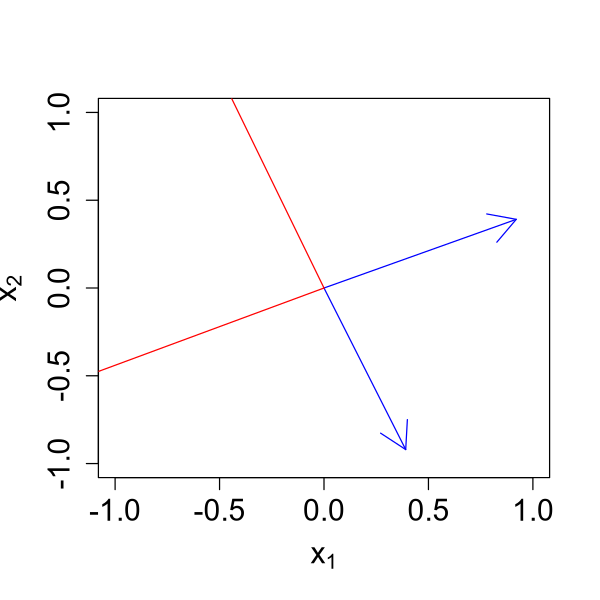

In [21]:
# norm(my_output$Y %*% my_output$R - my_output$S)
# norm(SimData$pre_data %*% t(my_output$Q) - my_output$Y)


# plot(x=my_output$S[,1], y=my_output$S[,2], asp=1, col=rgb(1,0,0,0.1))
plot(x=my_output$Y[,1], y=my_output$Y[,2], asp=1, col=rgb(1,0,0,0.1))
points(x=SimData$pre_data[,1], y=SimData$pre_data[,2], asp=1, col=rgb(0,0,1,0.1))

visualize_independent_directions_from_W(SimData$W, (my_output$W))


In [23]:
# norm(my_output$Y %*% my_output$R - my_output$S)
# norm(SimData$pre_data %*% t(my_output$Q) - my_output$Y)

norm((SimData$pre_data %*% (t(my_output$Q) %*% my_output$R)) - my_output$S, type="F")
norm((SimData$pre_data %*% (t(my_output$W))) - my_output$S, type="F")
norm(t(my_output$R)%*%my_output$Q - my_output$W)

[1] 4.823999e-15

[1] 4.823999e-15

[1] 0

In [39]:
split_r <- 0.5
my_estimator <- generate_estimator_with_logcondens(SimData, r=split_r, use_ICA=TRUE, plotting=FALSE)


[1] "ICA done!"
[1] "Marginal: "
[1] 1
[1] "Marginal: "
[1] 2
[1] "Marginal: "
[1] 3


-0.02062421,-0.02919082,-0.99936106
0.99902802,-0.03955063,-0.01946208
-0.03895725,-0.99879109,0.02997815


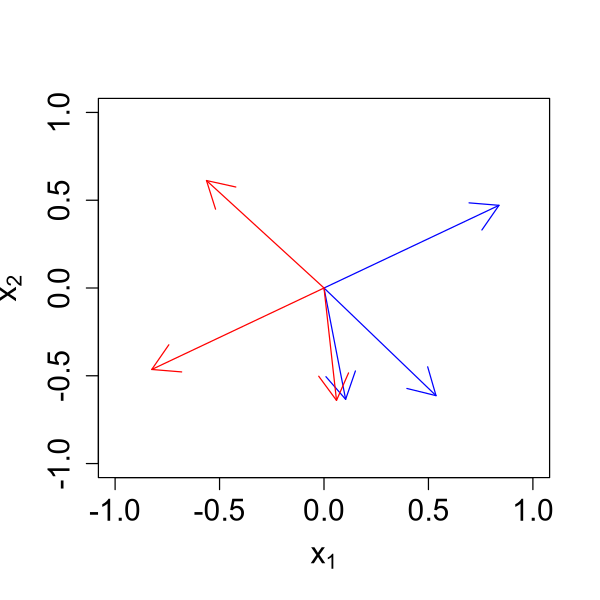

In [40]:
visualize_independent_directions_from_W(SimData$W, my_estimator$W_hat)